In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import string

from metpy.calc import wind_direction, wind_speed
from metpy.units import units

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import BoundaryNorm
from datetime import datetime, timedelta

from cmcrameri import cm

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Helvetica',
    'Nimbus Sans',
    'Arial',
    'Liberation Sans'
]

data_dir = '../data_out/'
fig_png_dir = '../figures_png/'
fig_pdf_dir = '../figures_pdf/'

In [2]:
def get_df_from_nc(ds, var):
    time_dim = ds[var].dims[0]
    height_dim = ds[var].dims[1]
    df = pd.DataFrame(ds[var].values, columns=ds[height_dim], index=pd.to_datetime(ds[time_dim],utc=True))
    return df

## Script settings

In [3]:
date = '2025-08-15'
days = 1

# resample WindRanger from 10min to 30min
res_wr = True

## Get data and resample

In [4]:
# load data
ds_icon = xr.open_dataset(data_dir + 'H3_ICON_v370_2030_cid35704_vertical_profile.nc')
ds_wr   = xr.open_dataset(data_dir + 'H3_Observations_WindRanger.nc')

df_i_wspd = get_df_from_nc(ds_icon, 'wspd')
df_i_wdir = get_df_from_nc(ds_icon, 'wdir')

if res_wr:
    df_wr_u = get_df_from_nc(ds_wr, 'u').resample('30min', origin='end_day').mean()
    df_wr_v = get_df_from_nc(ds_wr, 'v').resample('30min', origin='end_day').mean()

    # calc wind direction and speed
    df_wr_wspd = pd.DataFrame(wind_speed(df_wr_u.values * units('m/s'), df_wr_v.values * units('m/s')), index=df_wr_u.index, columns=df_wr_u.columns)
    df_wr_wdir = pd.DataFrame(wind_direction(df_wr_u.values * units('m/s'), df_wr_v.values * units('m/s')), index=df_wr_u.index, columns=df_wr_u.columns)
else:
    df_wr_wspd = get_df_from_nc(ds_wr, 'wspd')
    df_wr_wdir = get_df_from_nc(ds_wr, 'wdir')

# prepare dates
dt_from = pd.to_datetime(date,utc=True)
dt_to = dt_from + timedelta(days=days)

## Create plot

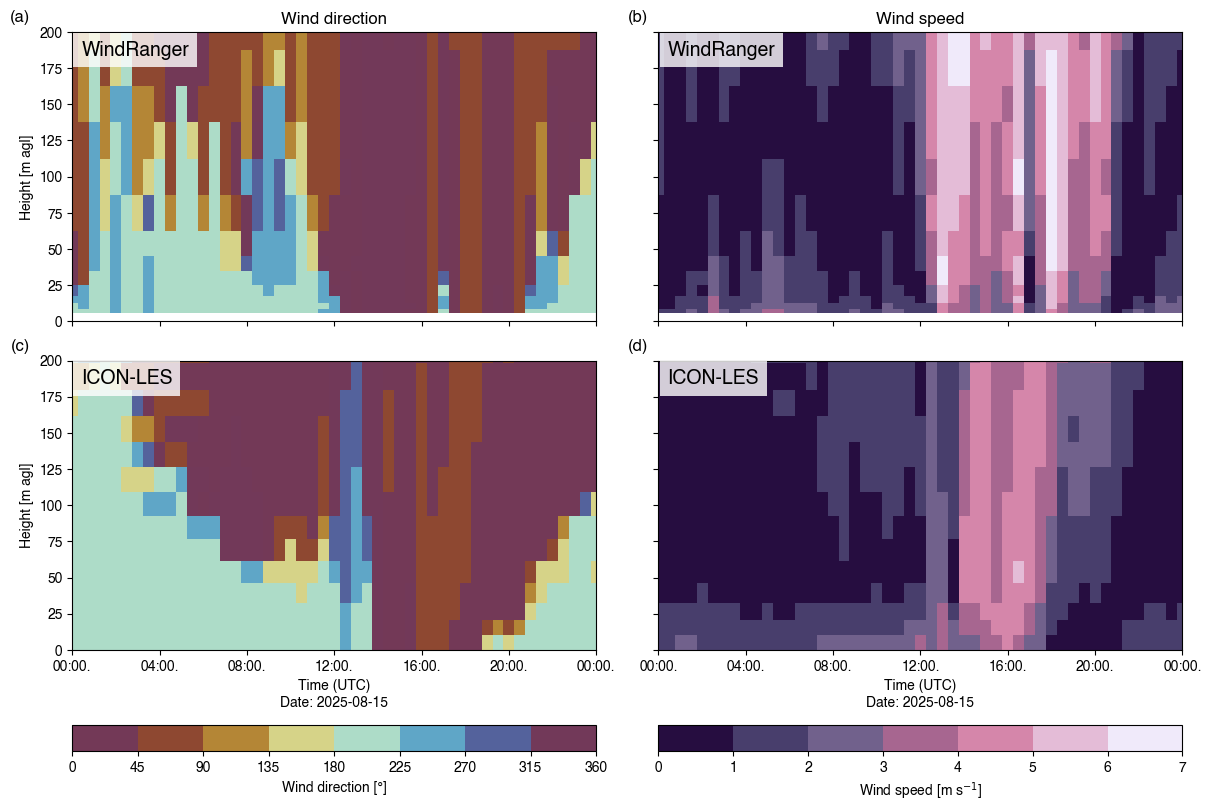

In [5]:
fig, axs = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(12, 8), constrained_layout=True)

# Wind Direction
cmap_wdir = cm.romaO
norm_wdir = BoundaryNorm(np.arange(0, 361, 45), cmap_wdir.N)

ax = axs[0][0]
pc = ax.pcolormesh(df_wr_wdir.index, df_wr_wdir.columns, df_wr_wdir.T, shading='auto', cmap=cmap_wdir, norm=norm_wdir)
ax.set_ylabel('Height [m agl]')
ax.set_title('Wind direction')

ax = axs[1][0]
pc = ax.pcolormesh(df_i_wdir.index, df_i_wdir.columns, df_i_wdir.T, shading='auto', cmap=cmap_wdir, norm=norm_wdir)
cbar = fig.colorbar(pc, ax=ax, orientation='horizontal')
cbar.set_label('Wind direction [°]')
cbar.set_ticks(np.arange(0, 361, 45))
ax.set_ylabel('Height [m agl]')

# Wind Speed
cmap_wspd = cm.acton
norm_wspd = BoundaryNorm(np.arange(0, 8, 1), cmap_wspd.N)

ax = axs[0][1]
pc = ax.pcolormesh(df_wr_wspd.index, df_wr_wspd.columns, df_wr_wspd.T, shading='auto', cmap=cmap_wspd, norm=norm_wspd)
ax.set_title('Wind speed')

ax = axs[1][1]
pc = ax.pcolormesh(df_i_wspd.index, df_i_wspd.columns, df_i_wspd.T, shading='auto', cmap=cmap_wspd, norm=norm_wspd)
cbar = fig.colorbar(pc, ax=ax, orientation='horizontal')
cbar.set_label('Wind speed [m s$^{-1}$]')

# Formatting
for i,ax in enumerate(axs.flat):
    ax.set_xlim(dt_from, dt_to)
    ax.set_ylim(0,200)

    if i // 2 == 0:
        l='WindRanger'
    else:
        l='ICON-LES'
        ax.set_xlabel(f"Time (UTC)\nDate: {dt_from.strftime('%Y-%m-%d')}")
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M.'))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))

    # box in upper left corner
    ax.text(
        0.017, 0.97, l, ha="left", va="top", fontsize=14,
        transform=ax.transAxes,  # axis coordinates
        bbox=dict(
            facecolor="white", edgecolor="none",
            alpha=0.8, boxstyle="square,pad=0.4"
        )
    )

# panel letters
for ax, letter in zip(axs.flat, string.ascii_lowercase):
    if letter in ['a','c']: x=-0.08
    else: x=-0.02
    ax.text(
        x, 1.025, f'({letter})',
        transform=ax.transAxes,
        fontsize=12, fontweight='bold',
        va='bottom', ha='right'
    )

plt.savefig(fig_png_dir + f'HEF_WindRanger_ICON_profile_{dt_from.strftime('%Y%m%d')}.png', dpi=150, bbox_inches = 'tight', pad_inches = 0)
plt.savefig(fig_pdf_dir + f'HEF_WindRanger_ICON_profile_{dt_from.strftime('%Y%m%d')}.pdf', dpi=300, bbox_inches = 'tight', pad_inches = 0)
plt.show()